In [1]:
import pandas as pd
import numpy as np

In [2]:
low_mass_central_df = pd.read_parquet ('../low_mass_central_df_annuli_revised.parquet')

In [3]:
low_mass_central_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
15916,312415.0,0.071176,8.105450,-3.995854,7.655353,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15917,312415.0,0.213527,8.175151,-3.359508,7.247262,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15918,312415.0,0.355879,7.912692,-2.209567,6.888073,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15919,312415.0,0.498230,7.599713,-4.369588,6.704756,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
15920,312415.0,0.640582,7.371823,-4.605686,6.710869,1,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.83374,45.328607,0.155899,0.12591,9.881313e-324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63077,755674.0,0.445985,7.800349,-4.208787,4.745439,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63078,755674.0,0.743309,7.416642,-4.607568,4.934123,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63079,755674.0,1.040633,7.098891,-4.875287,4.386663,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00
63080,755674.0,1.337956,6.887413,-5.109916,4.235222,1,0.0,0.155144,0.00000,0,40.501854,0.001908,0.0,0.000000e+00,2.82078,32.637203,-0.134313,0.00000,0.000000e+00


In [4]:
# # calculating star forming efficiency (SFE) and gas fraction 
# low_mass_satellite_df['SFE'] = 10**(low_mass_satellite_df['avg_SFR'] - low_mass_satellite_df['avg_gas_mass'])
# low_mass_satellite_df['f_gas'] = 10**(low_mass_satellite_df['avg_gas_mass'] - low_mass_satellite_df['avg_s_mass'])

In [5]:
# # remove the rows where the sfr_indicator is 0.0 -> implies artificially imposed minimum
# low_mass_satellite_df = low_mass_satellite_df[low_mass_satellite_df['sfr_indicator'] != 0.0]
# low_mass_satellite_df

In [6]:
# star forming quenching vector value = 0
low_mass_central_df = low_mass_central_df[low_mass_central_df['quenching_vector'] != 1]
low_mass_central_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
15917,312415.0,0.213527,8.175151,-3.359508,7.247262,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.833740,45.328607,0.155899,0.125910,9.881313e-324
15918,312415.0,0.355879,7.912692,-2.209567,6.888073,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.833740,45.328607,0.155899,0.125910,9.881313e-324
15922,312415.0,0.925285,7.054781,-4.070769,6.963181,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.833740,45.328607,0.155899,0.125910,9.881313e-324
15923,312415.0,1.067636,6.900457,-3.289078,7.173378,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.833740,45.328607,0.155899,0.125910,9.881313e-324
15924,312415.0,1.209988,6.796739,-2.832557,7.367570,0,0.0,0.509563,0.00105,0,64.871277,0.295028,0.0,9.881313e-324,980.833740,45.328607,0.155899,0.125910,9.881313e-324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63036,702046.0,0.178702,8.114720,-1.296303,7.687575,0,0.0,0.142014,0.00000,0,48.393726,0.277645,0.0,0.000000e+00,4.553244,-0.161578,-0.134313,0.121859,0.000000e+00
63037,702046.0,0.536105,8.014228,-1.850880,7.689039,0,0.0,0.142014,0.00000,0,48.393726,0.277645,0.0,0.000000e+00,4.553244,-0.161578,-0.134313,0.121859,0.000000e+00
63038,702046.0,0.893508,7.557265,-1.612207,7.680125,0,0.0,0.142014,0.00000,0,48.393726,0.277645,0.0,0.000000e+00,4.553244,-0.161578,-0.134313,0.121859,0.000000e+00
63039,702046.0,1.250912,7.199104,-2.294763,7.566593,0,0.0,0.142014,0.00000,0,48.393726,0.277645,0.0,0.000000e+00,4.553244,-0.161578,-0.134313,0.121859,0.000000e+00


In [7]:
low_mass_central_df.shape

(18307, 19)

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import RobustScaler

# 'BHMass', 'BHCum_QM', 'Mhalo', 'overdens', and 'bulge' are the features wer are testing
low_mass_central_df = low_mass_central_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "gas_mass","avg_gas_mass", "quenching_vector", "Bfld", "veldisp", "BH_AGN"])

<Axes: >

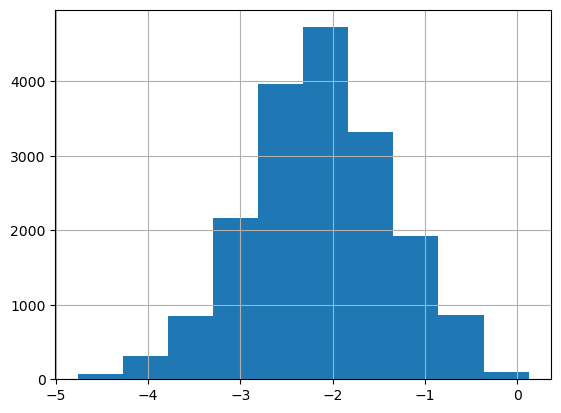

In [9]:
low_mass_central_df['avg_SFR'].hist()

In [10]:
# this indicates that there are more instances of the delta rate on the left

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

galaxy_ids = low_mass_central_df['subID']

feature_importances_list = []
feature_names = None
test_mses = []
train_mses = []


for seed in range(10):
    # split galaxies into 50% training and 50% testing
    unique_galaxies = np.unique(low_mass_central_df['subID'])
    train_galaxies, test_galaxies = train_test_split(unique_galaxies, test_size=0.5, random_state=seed)

    # assign spaxels based on galaxy split
    train_data = low_mass_central_df[low_mass_central_df['subID'].isin(train_galaxies)]
    test_data = low_mass_central_df[low_mass_central_df['subID'].isin(test_galaxies)]

    X_train, y_train = train_data.drop(columns=['avg_SFR', 'subID']), train_data['avg_SFR']
    X_test, y_test = test_data.drop(columns=['avg_SFR', 'subID']), test_data['avg_SFR']
    
    
    if feature_names is None:
        feature_names = X_train.columns.tolist()

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    param_grid = {
    'n_estimators': [100,200, 300, 400, 500],  
    'max_depth': [50, 100, 150, 200, 250],  
    'min_samples_split': [50, 100, 150],  
    'min_samples_leaf': [100, 200, 300, 400],  
    'max_features': [None], 
    'bootstrap': [True],
    }
    rf_regressor = RandomForestRegressor(random_state=seed, n_jobs=-1)
    cv = KFold(n_splits=5, shuffle=True, random_state=seed)

    random_search = RandomizedSearchCV(
    estimator=rf_regressor, 
    param_distributions=param_grid, 
    n_iter=10,
    cv=cv, 
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=seed,
    verbose=2)

    random_search.fit(X_train_scaled, y_train)

    best_rf_regressor = random_search.best_estimator_

    best_rf_regressor.fit(X_train_scaled, y_train)
    
    y_train_pred = best_rf_regressor.predict(X_train_scaled)
    y_test_pred = best_rf_regressor.predict(X_test_scaled)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_mses.append(train_mse)
    test_mses.append(test_mse)
    
    feature_importances_list.append(best_rf_regressor.feature_importances_)
#     print(random_search.best_params_)
    print(f"Run {seed+1}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")

print("\nAverage MSE over 10 runs:")
print(f"Train MSE: Mean = {np.mean(train_mses):.4f}, Std = {np.std(train_mses):.4f}")
print(f"Test MSE:  Mean = {np.mean(test_mses):.4f}, Std = {np.std(test_mses):.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, max_depth=200, max_features=None, min_samples_leaf=200, min_samples_split=150, n_estimators=400; total time=   6.2s
[CV] END bootstrap=True, max_depth=200, max_features=None, min_samples_leaf=200, min_samples_split=150, n_estimators=400; total time=   6.2s
[CV] END bootstrap=True, max_depth=200, max_features=None, min_samples_leaf=200, min_samples_split=150, n_estimators=400; total time=   6.3s
[CV] END bootstrap=True, max_depth=200, max_features=None, min_samples_leaf=200, min_samples_split=150, n_estimators=400; total time=   6.6s
[CV] END bootstrap=True, max_depth=200, max_features=None, min_samples_leaf=200, min_samples_split=150, n_estimators=400; total time=   6.6s
[CV] END bootstrap=True, max_depth=200, max_features=None, min_samples_leaf=100, min_samples_split=100, n_estimators=400; total time=   7.1s
[CV] END bootstrap=True, max_depth=200, max_features=None, min_samples_leaf=100, min_samples_


=== Average Feature Importances ===
      Feature  Mean Importance   Std Dev
1  avg_s_mass         0.915084  0.004923
6       bulge         0.038064  0.004220
0   bin_radii         0.022474  0.002533
3      BHMass         0.010355  0.001683
2      s_mass         0.006268  0.001597
4       Mhalo         0.004866  0.000619
5    overdens         0.002889  0.000579


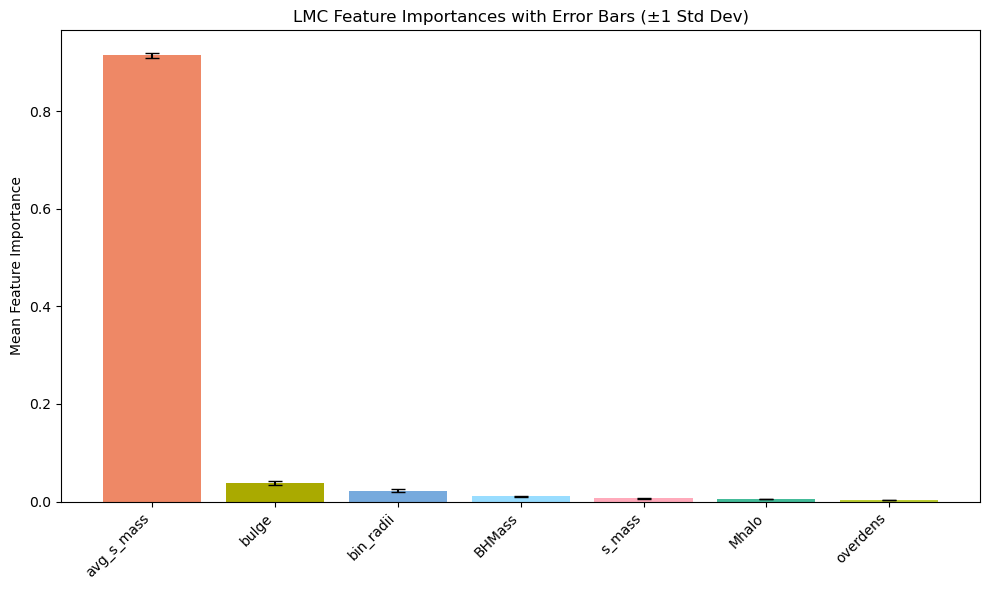

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
feature_colors = {
    'bin_radii': '#77AADD',
    'avg_s_mass': '#EE8866',
    's_mass': '#FFAABB',
    'BHMass': '#99DDFF',
    'Mhalo': '#44BB99',
    'overdens': '#BBCC33',
    'bulge': '#AAAA00',
    'BH_AGN': '#DDDDDD',
}

# importances + stds across 10 runs
importances_array = np.array(feature_importances_list)
importance_means = np.mean(importances_array, axis=0)
importance_stds = np.std(importances_array, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': importance_means,
    'Std Dev': importance_stds
}).sort_values(by='Mean Importance', ascending=False)

print("\n=== Average Feature Importances ===")
print(importance_df)

colors = [feature_colors[feat] for feat in importance_df['Feature']]
# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Mean Importance'], yerr=importance_df['Std Dev'], capsize=5, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Feature Importance")
plt.title("LMC Feature Importances with Error Bars (±1 Std Dev)")
plt.tight_layout()
plt.show()

In [13]:
low_mass_central_df.corr()

,subID,bin_radii,avg_s_mass,avg_SFR,s_mass,BHMass,Mhalo,overdens,bulge
subID,1.000000,0.013321,-0.217399,-0.170600,-0.674768,-0.616069,-0.766577,-0.030488,-0.102330
bin_radii,0.013321,1.000000,-0.797716,-0.530915,-0.016384,-0.025061,-0.000214,-0.004126,-0.020355
avg_s_mass,-0.217399,-0.797716,1.000000,0.716473,0.356341,0.384364,0.097359,0.035343,-0.052705
avg_SFR,-0.170600,-0.530915,0.716473,1.000000,0.247018,0.261136,0.068096,0.015158,-0.155457
s_mass,-0.674768,-0.016384,0.356341,0.247018,1.000000,0.898742,0.364972,0.041371,0.018739
BHMass,-0.616069,-0.025061,0.384364,0.261136,0.898742,1.000000,0.325332,0.047819,0.092509
Mhalo,-0.766577,-0.000214,0.097359,0.068096,0.364972,0.325332,1.000000,0.059571,0.084510
overdens,-0.030488,-0.004126,0.035343,0.015158,0.041371,0.047819,0.059571,1.000000,-0.011617
bulge,-0.102330,-0.020355,-0.052705,-0.155457,0.018739,0.092509,0.084510,-0.011617,1.000000


In [14]:
import os
# Define your directory and file name
directory = 'rf_regression_outputs'
filename = 'lmc_rf_reg.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
importance_df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

DataFrame saved to rf_regression_outputs/lmc_rf_reg.csv


In [15]:
train_mean = round(np.mean(train_mses), 2)
test_mean = round(np.mean(test_mses), 2)

df = pd.DataFrame({
    'Train MSE': [train_mean],
    'Test MSE': [test_mean]
})

print(df)
import os
# Define your directory and file name
directory = 'rf_regression_outputs'
filename = 'lmc_rf_reg_mse.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

   Train MSE  Test MSE
0       0.25      0.26
DataFrame saved to rf_regression_outputs/lmc_rf_reg_mse.csv
